# SoilGrids Auxiliary Variables — EDA

Loads all 6 SoilGrids variables (depth-weighted mean across 0–30 cm)
and produces publication-ready maps for the thesis Data chapter.

In [1]:
import sys
import os
from pathlib import Path

ROOT = Path().resolve()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'src'))
print(f'Working directory: {ROOT}')

Working directory: /Users/etomengoi/Desktop/precip_interpolation_thesis


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pyproj import Transformer

from thesis.config import Config
from thesis.data.soilgrids import SoilGridsSource

## Load soil rasters

Each variable is depth-weighted averaged across 0–5 cm, 5–15 cm, 15–30 cm
(weights proportional to layer thickness: 5, 10, 15 cm).
Values below physical minimum are masked as nodata artifacts from reprojection.

In [3]:
cfg = Config()
sa  = cfg.study_area

SOIL_VARS = ['bulk_density', 'clay', 'sand', 'silt', 'soc', 'water_10kpa']

LABELS = {
    'bulk_density': 'Bulk density\n(cg cm$^{-3}$)',
    'clay':         'Clay content\n(g kg$^{-1}$)',
    'sand':         'Sand content\n(g kg$^{-1}$)',
    'silt':         'Silt content\n(g kg$^{-1}$)',
    'soc':          'Soil organic carbon\n(dg kg$^{-1}$)',
    'water_10kpa':  'Plant-available water\nat $-$10 kPa (cm$^3$/100 cm$^3$)',
}

CMAPS = {
    'bulk_density': 'YlOrBr',
    'clay':         'YlOrRd',
    'sand':         'YlGn',
    'silt':         'PuBu',
    'soc':          'Greens',
    'water_10kpa':  'Blues',
}

rasters = {}
for var in SOIL_VARS:
    src = SoilGridsSource(cfg, variable=var, depth=None)  # depth-averaged
    arr, _ = src.load_raster(
        sa.lon_min, sa.lat_min, sa.lon_max, sa.lat_max, sa.grid_resolution_m
    )
    arr = arr.copy()
    arr[arr < 0] = np.nan  # mask nodata artifacts from reprojection
    rasters[var] = arr
    print(f'{var:15s}  p2={np.nanpercentile(arr,2):.1f}  '
          f'mean={np.nanmean(arr):.1f}  p98={np.nanpercentile(arr,98):.1f}')

bulk_density     p2=27.6  mean=124.2  p98=148.4
clay             p2=30.9  mean=167.5  p98=316.4
sand             p2=78.9  mean=450.0  p98=784.2
silt             p2=53.7  mean=309.8  p98=564.0
soc              p2=70.3  mean=302.8  p98=624.5
water_10kpa      p2=49.1  mean=352.4  p98=427.5


## Panel map — all 6 variables

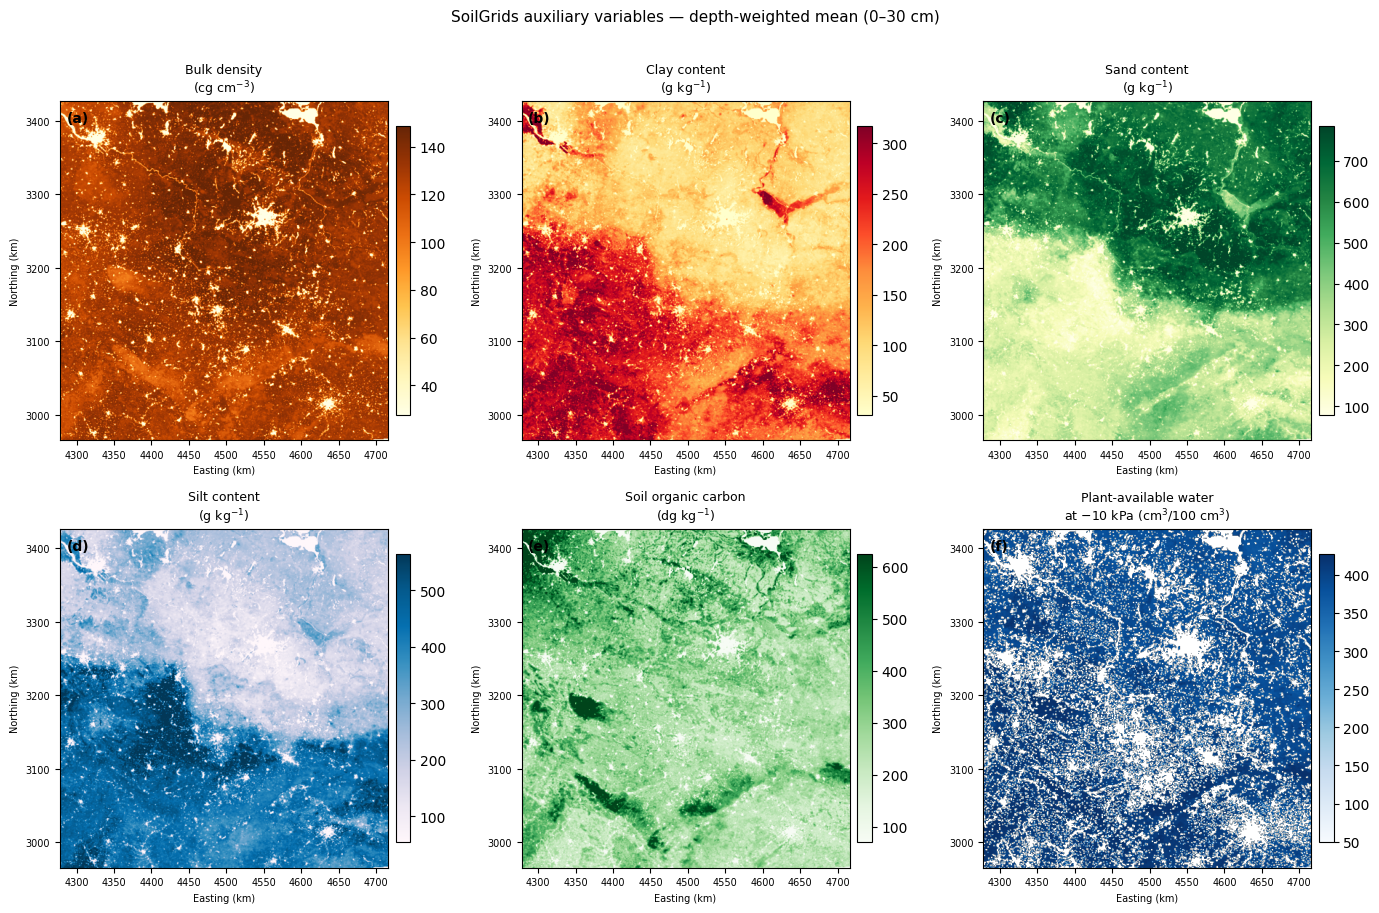

In [4]:
t = Transformer.from_crs('EPSG:4326', sa.target_crs, always_xy=True)
x_min, y_min = t.transform(sa.lon_min, sa.lat_min)
x_max, y_max = t.transform(sa.lon_max, sa.lat_max)
extent_km = [x_min/1e3, x_max/1e3, y_min/1e3, y_max/1e3]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, var, label in zip(axes.ravel(), SOIL_VARS, 'abcdef'):
    arr = rasters[var]
    im = ax.imshow(
        arr, origin='upper', extent=extent_km, cmap=CMAPS[var], aspect='auto',
        vmin=np.nanpercentile(arr, 2), vmax=np.nanpercentile(arr, 98),
    )
    plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    ax.set_title(LABELS[var], fontsize=9)
    ax.set_xlabel('Easting (km)', fontsize=7)
    ax.set_ylabel('Northing (km)', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.text(0.02, 0.97, f'({label})', transform=ax.transAxes,
            fontsize=10, fontweight='bold', va='top')

fig.suptitle('SoilGrids auxiliary variables — depth-weighted mean (0–30 cm)', fontsize=11, y=1.01)
fig.tight_layout()
plt.show()

## Save figure

In [5]:
OUT = ROOT / 'images' / 'fig_soilgrids.png'
fig.savefig(OUT, dpi=180, bbox_inches='tight')
print(f'Saved → {OUT}')

Saved → /Users/etomengoi/Desktop/precip_interpolation_thesis/images/fig_soilgrids.png
